# OMS with a different moving background in the center vs surround

This notebook generates the plots for Supplementary Figure 7, which showcases the response of a OMS unit to a different moving background in the center vs surround.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from retina import train, analysis
matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

In [2]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")
model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")

In [3]:
def plot_grating_and_raster(title, grating, raster_x, raster_y, ax_grating, ax_raster):
    ax_grating.imshow(grating, cmap="Greys", vmin=-1, vmax=1)
    ax_raster.scatter(raster_x, raster_y+1, s=1, c="black")
    ax_grating.set_title(title, fontsize=14, pad=8)
    ax_grating.set_xticks([])
    ax_grating.set_yticks([])
    ax_grating.spines["top"].set_linewidth(2)
    ax_grating.spines["bottom"].set_linewidth(2)
    ax_grating.spines["left"].set_linewidth(2)
    ax_grating.spines["right"].set_linewidth(2)
    
    ax_raster.spines["top"].set_visible(False)
    ax_raster.spines["right"].set_visible(False)
    ax_raster.spines["bottom"].set_linewidth(2)
    ax_raster.spines["left"].set_linewidth(2)
    ax_raster.xaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax_raster.yaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax_raster.set_yticks([1, 8])
    ax_raster.set_xticks([0, 240, 480, 720])
    ax_raster.set_xticklabels([0, 1, 2, 3])
    ax_raster.set_xlabel("Time (s)", fontsize=14, labelpad=8)
    ax_raster.set_ylabel("Trial", fontsize=14, labelpad=2)

In [4]:
torch.manual_seed(24)
unit_idx=13
differential_motion = analysis.DifferentialMotion(model, unit_idx=unit_idx, theta=np.pi, spatial_freq=0.06, temporal_freq=2, y0=10, x0=13, r=3, lum=0.5, moving_background=True)

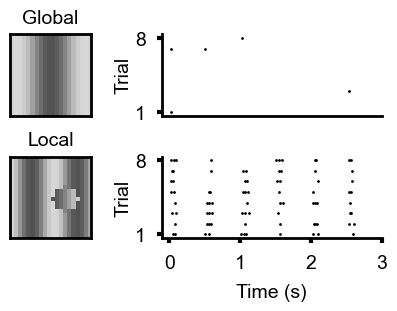

In [5]:
fig = plt.figure(constrained_layout=True, figsize=(4, 3))
spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig)
ax1 = fig.add_subplot(spec[0, :2])
ax2 = fig.add_subplot(spec[0, 2:]) 
ax3 = fig.add_subplot(spec[1, :2])
ax4 = fig.add_subplot(spec[1, 2:])

plot_grating_and_raster("Global", differential_motion.grating[420-40], *differential_motion.global_raster, ax1, ax2)
ax2.set_xticks([])
ax2.set_xlabel("")
plot_grating_and_raster("Local", differential_motion.masked_grating[420-40], *differential_motion.local_raster, ax3, ax4)
plt.savefig(f"{root}/figures/supp/motion_selectivity_raster.svg", format="svg", transparent=False, bbox_inches="tight")